<img src="https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/media/logo/newebac_logo_black_half.png" alt="ebac-logo">

---

# **Módulo** | Big Data II - Armazenamento
Caderno de **Exercícios**<br>
Professor [André Perez](https://www.linkedin.com/in/andremarcosperez/)

---

# **Tópicos**

<ol type="1">
  <li>Introdução;</li>
  <li>Orientação a coluna;</li>
  <li>Particionamento.</li>
</ol>

---

# **Exercícios**

## 1\. Particionamento e orientação a coluna.

Replique as atividades da aula 3 em sua conta da AWS.

1.1. Faça o download do arquivo `crime.csv` (fonte [Kaggle](https://www.kaggle.com/yamqwe/chicago-crimee?select=chicago_crime_2014.csv)).

In [ ]:
!wget https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/crime.csv -q -O crime.csv

1.2. Leia os dados em um DataFrame Pandas e crie a coluna `reference_date`.

In [ ]:
# Solução do item 1.2.
import pandas as pd
import datetime as dt
df = pd.read_csv('crime.csv')
df['reference_date'] = pd.to_datetime(df['Date']).dt.date
df.drop('Date', axis=1, inplace=True)

In [ ]:
df.head()

,index,ID,Case Number,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude,reference_date
0,0,9446824,HX100141,0000X W ILLINOIS ST,0460,BATTERY,SIMPLE,STREET,False,False,1831,18,42.0,8.0,08B,41.890828,-87.630235,2014-01-01
1,1,9446748,HX100020,006XX N DEARBORN ST,0890,THEFT,FROM BUILDING,BAR OR TAVERN,False,False,1832,18,42.0,8.0,06,41.893542,-87.629702,2014-01-01
2,2,9446758,HX100030,052XX W RACE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,1523,15,28.0,25.0,14,41.890046,-87.756333,2014-01-01
3,3,9446760,HX100027,053XX W WELLINGTON AVE,0460,BATTERY,SIMPLE,APARTMENT,True,False,2514,25,31.0,19.0,08B,41.935011,-87.759739,2014-01-01
4,4,9446764,HX100054,014XX W LEXINGTON ST,0460,BATTERY,SIMPLE,STREET,False,False,1231,12,25.0,28.0,08B,41.872509,-87.663069,2014-01-01


1.3. Persista o dado no DataFrame em um arquivo csv e em arquivos parquet, estes últimos comprimidos e particionados pela coluna `reference_date`.

In [ ]:
print(len(df.columns))

18


In [ ]:
# Solução do item 1.3.
df.to_csv('crimes_csv.csv', index=False)

In [ ]:
#df.to_parquet('./crimes_parquet', engine='pyarrow', compression='gzip', partition_cols='reference_date')

In [ ]:
df.to_parquet(
    './crimes_parquet',
    engine='pyarrow',
    partition_cols=['reference_date'],
    compression='snappy',
    index=False
)


##################TESTES####################

In [ ]:
teste = pd.read_parquet('/content/crimes_parquet/reference_date=2014-01-01/1755b1a32ac949ebb758d23d2fb0892c-0.parquet', engine='pyarrow')

In [ ]:
teste.head()

,index,ID,Case Number,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
0,0,9446824,HX100141,0000X W ILLINOIS ST,0460,BATTERY,SIMPLE,STREET,False,False,1831,18,42.0,8.0,08B,41.890828,-87.630235
1,1,9446748,HX100020,006XX N DEARBORN ST,0890,THEFT,FROM BUILDING,BAR OR TAVERN,False,False,1832,18,42.0,8.0,06,41.893542,-87.629702
2,2,9446758,HX100030,052XX W RACE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,1523,15,28.0,25.0,14,41.890046,-87.756333
3,3,9446760,HX100027,053XX W WELLINGTON AVE,0460,BATTERY,SIMPLE,APARTMENT,True,False,2514,25,31.0,19.0,08B,41.935011,-87.759739
4,4,9446764,HX100054,014XX W LEXINGTON ST,0460,BATTERY,SIMPLE,STREET,False,False,1231,12,25.0,28.0,08B,41.872509,-87.663069


In [ ]:
agg_df = teste['Location Description'].value_counts()


In [ ]:
agg_df.head()

,count
Location Description,
RESIDENCE,361
APARTMENT,197
STREET,134
SIDEWALK,61
OTHER,56


##################TESTES####################

1.4. Crie os recursos no AWS S3 e AWS IAM e persista os dados em seus respectivos *buckets*.

In [ ]:
# Solução do item 1.4.
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 6.3 MB/s eta 0:00:00


In [ ]:
from getpass import getpass

aws_id = getpass()

··········


In [ ]:
aws_key = getpass()

··········


In [ ]:
import boto3
client = boto3.client(
    's3',
    aws_access_key_id=aws_id,
    aws_secret_access_key=aws_key
)

In [ ]:
import os
BUCKET_CSV = 'thiago-modulo-41-csv'

client.upload_file('crimes_csv.csv', BUCKET_CSV, 'crimes_csv.csv')

In [ ]:
BUCKET_PARQUET = 'thiago-modulo-41-parquet'

i = 0

for root, dirs, files in os.walk('./crimes_parquet'):
  elapsed = f'{round(100*i/365, 2)}%'
  print(elapsed)
  for file in files:
    path = os.path.join(root, file)
    bucket_path = '/'.join(path.split(sep='/')[2:])
    client.upload_file(path, BUCKET_PARQUET, bucket_path)
  i = i + 1

0.0%
0.27%
0.55%
0.82%
1.1%
1.37%
1.64%
1.92%
2.19%
2.47%
2.74%
3.01%
3.29%
3.56%
3.84%
4.11%
4.38%
4.66%
4.93%
5.21%
5.48%
5.75%
6.03%
6.3%
6.58%
6.85%
7.12%
7.4%
7.67%
7.95%
8.22%
8.49%
8.77%
9.04%
9.32%
9.59%
9.86%
10.14%
10.41%
10.68%
10.96%
11.23%
11.51%
11.78%
12.05%
12.33%
12.6%
12.88%
13.15%
13.42%
13.7%
13.97%
14.25%
14.52%
14.79%
15.07%
15.34%
15.62%
15.89%
16.16%
16.44%
16.71%
16.99%
17.26%
17.53%
17.81%
18.08%
18.36%
18.63%
18.9%
19.18%
19.45%
19.73%
20.0%
20.27%
20.55%
20.82%
21.1%
21.37%
21.64%
21.92%
22.19%
22.47%
22.74%
23.01%
23.29%
23.56%
23.84%
24.11%
24.38%
24.66%
24.93%
25.21%
25.48%
25.75%
26.03%
26.3%
26.58%
26.85%
27.12%
27.4%
27.67%
27.95%
28.22%
28.49%
28.77%
29.04%
29.32%
29.59%
29.86%
30.14%
30.41%
30.68%
30.96%
31.23%
31.51%
31.78%
32.05%
32.33%
32.6%
32.88%
33.15%
33.42%
33.7%
33.97%
34.25%
34.52%
34.79%
35.07%
35.34%
35.62%
35.89%
36.16%
36.44%
36.71%
36.99%
37.26%
37.53%
37.81%
38.08%
38.36%
38.63%
38.9%
39.18%
39.45%
39.73%
40.0%
40.27%
40.55%
40.82%
41

1.5. Crie os recursos no AWS Athena e execute as consultas SQL da aula.

In [ ]:
# Solução do item 1.5.


Tabela CSV



```sql

CREATE EXTERNAL TABLE IF NOT EXISTS `default`.`crime_csv` (
  `index` bigint,
  `id` bigint,
  `case_number` string,
  `block` string,
  `iucr` string,
  `primary_type` string,
  `description` string,
  `location_description` string,
  `arrest` boolean,
  `domestic` boolean,
  `beat` bigint,
  `district` bigint,
  `ward` double,
  `community_area` double,
  `fbi_code` string,
  `latitude` double,
  `longitude` double,
  `reference_date` string
  )
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.lazy.LazySimpleSerDe'
WITH SERDEPROPERTIES ('field.delim' = ',')
STORED AS INPUTFORMAT 'org.apache.hadoop.mapred.TextInputFormat' OUTPUTFORMAT 'org.apache.hadoop.hive.ql.io.HiveIgnoreKeyTextOutputFormat'
LOCATION 's3://thiago-modulo-41-csv/'
TBLPROPERTIES ('classification' = 'csv');

```

Tabela Parquet

```sql
CREATE EXTERNAL TABLE IF NOT EXISTS `default`.`crime_parquet` (
  `index` bigint,
  `id` bigint,
  `case number` string,
  `block` string,
  `iucr` string,
  `primary type` string,
  `description` string,
  `location description` string,
  `arrest` boolean,
  `domestic` boolean,
  `beat` bigint,
  `district` bigint,
  `ward` double,
  `community area` double,
  `fbi code` string,
  `latitude` double,
  `longitude` double
  )
PARTITIONED BY(
  `reference_date` date
  )
STORED AS PARQUET
LOCATION 's3://thiago-modulo-41-parquet/';

```

**Querys 0**

Primeiramente vamos ver as 5 primeiras linhas

```sql
SELECT *
FROM crime_csv
LIMIT 5
```
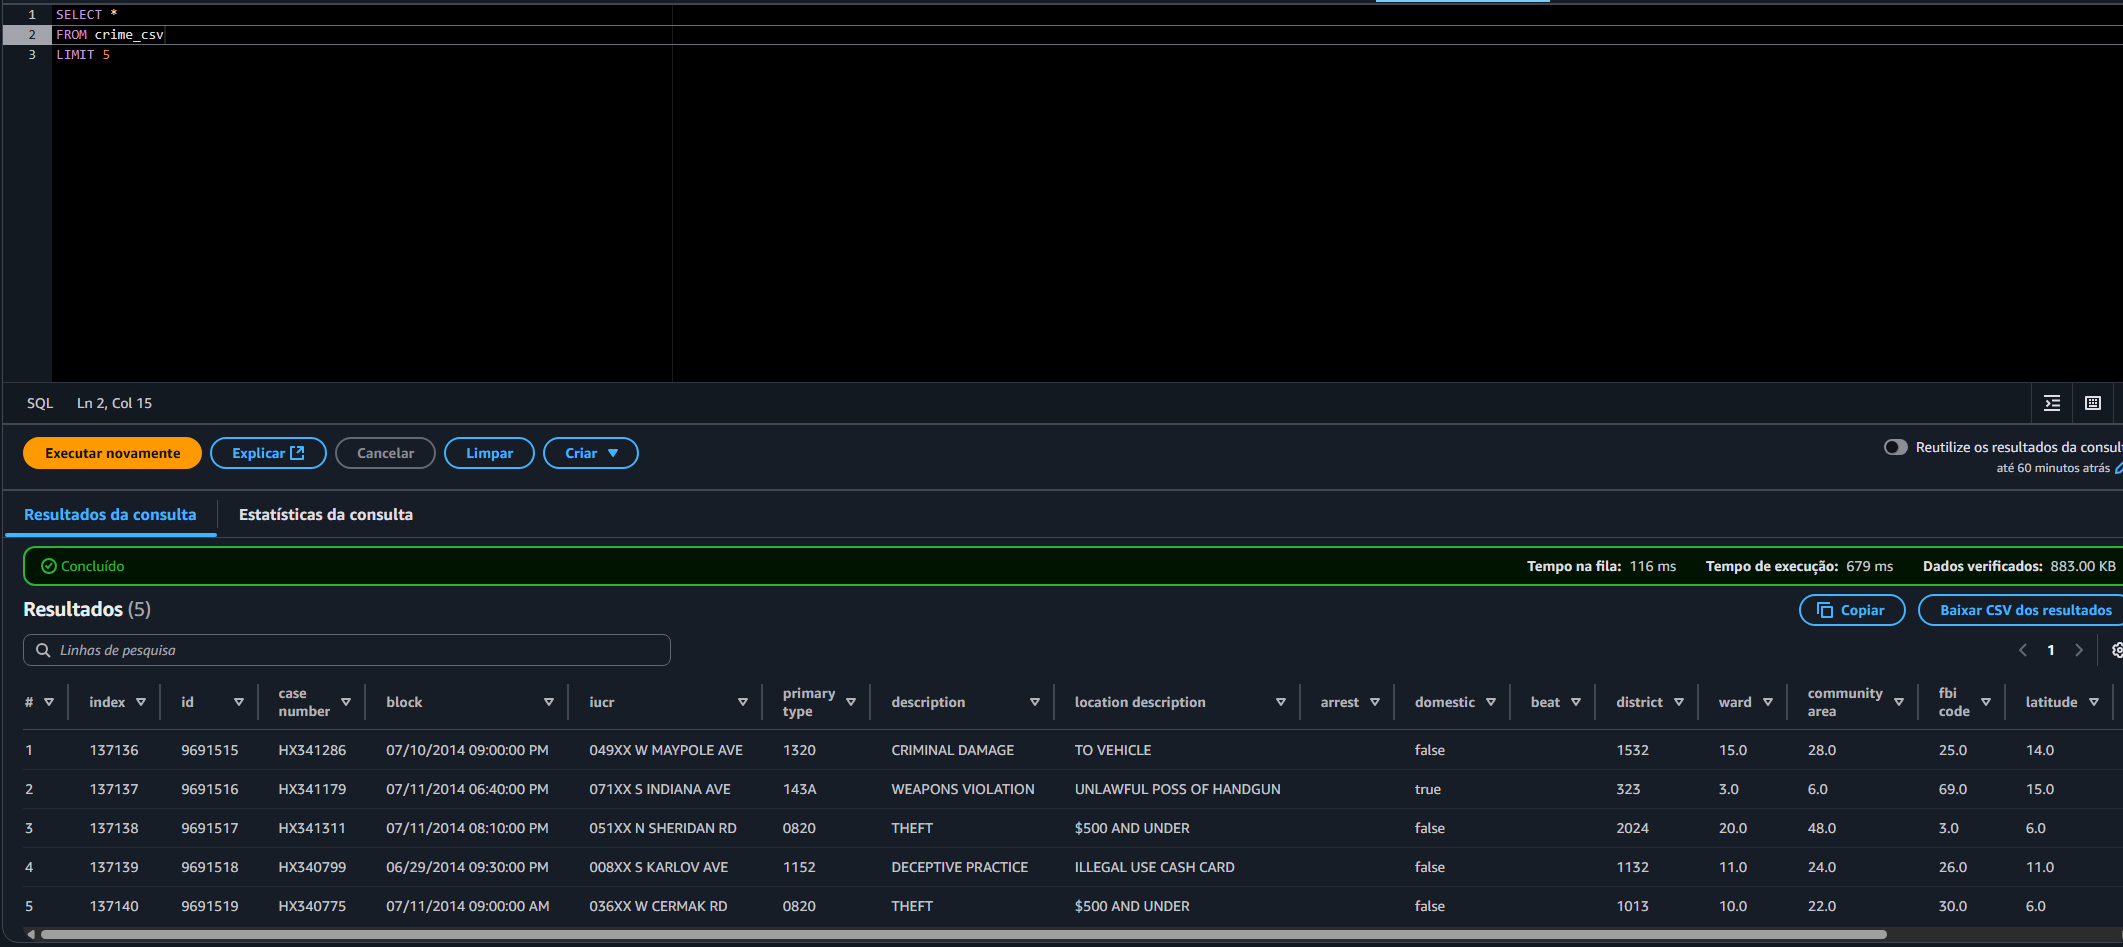

```sql
SELECT *
FROM crime_parquet
LIMIT 5
```
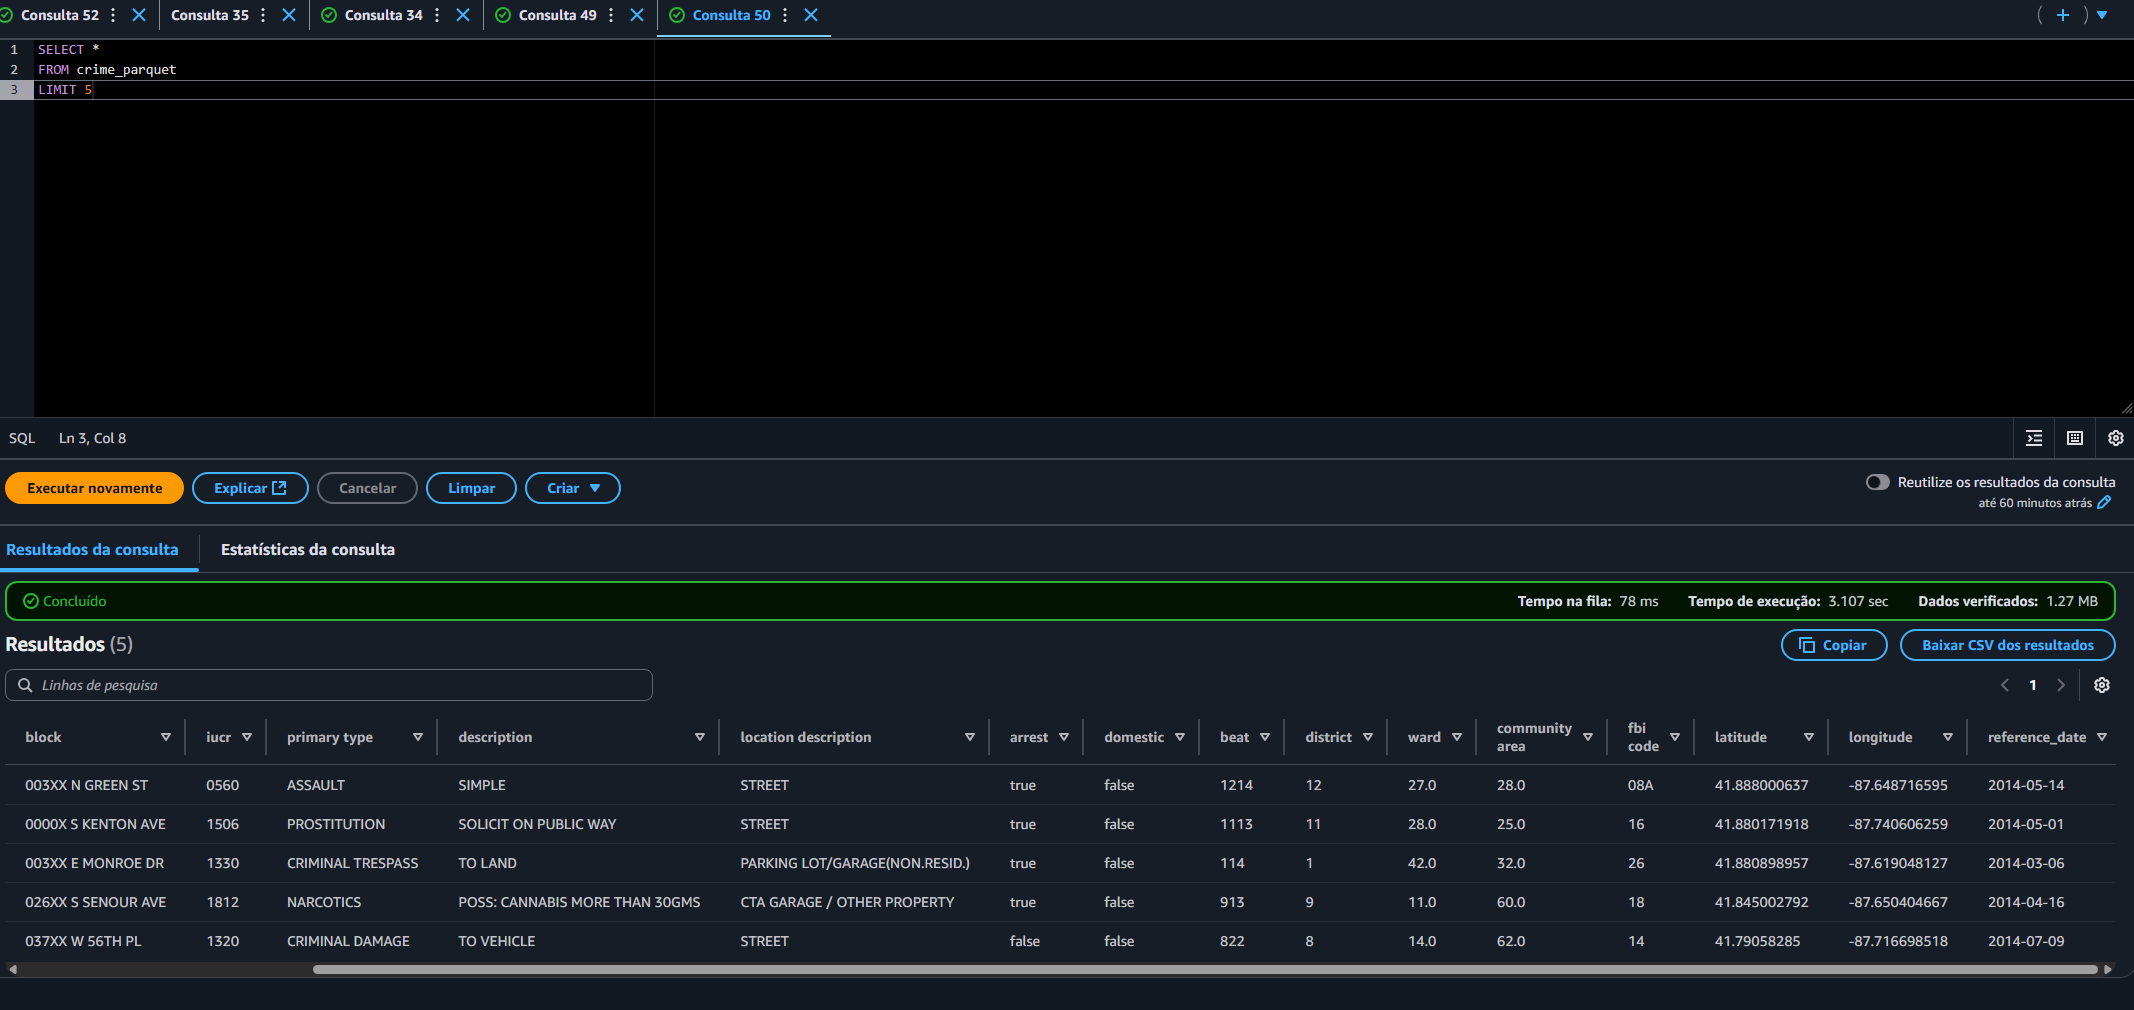

**Querys 1**

Começando as cunsultas da aula

```sql
SELECT "location description", COUNT(1) as "amount"
FROM crime_csv
GROUP BY 1
ORDER BY 2 DESC;
```


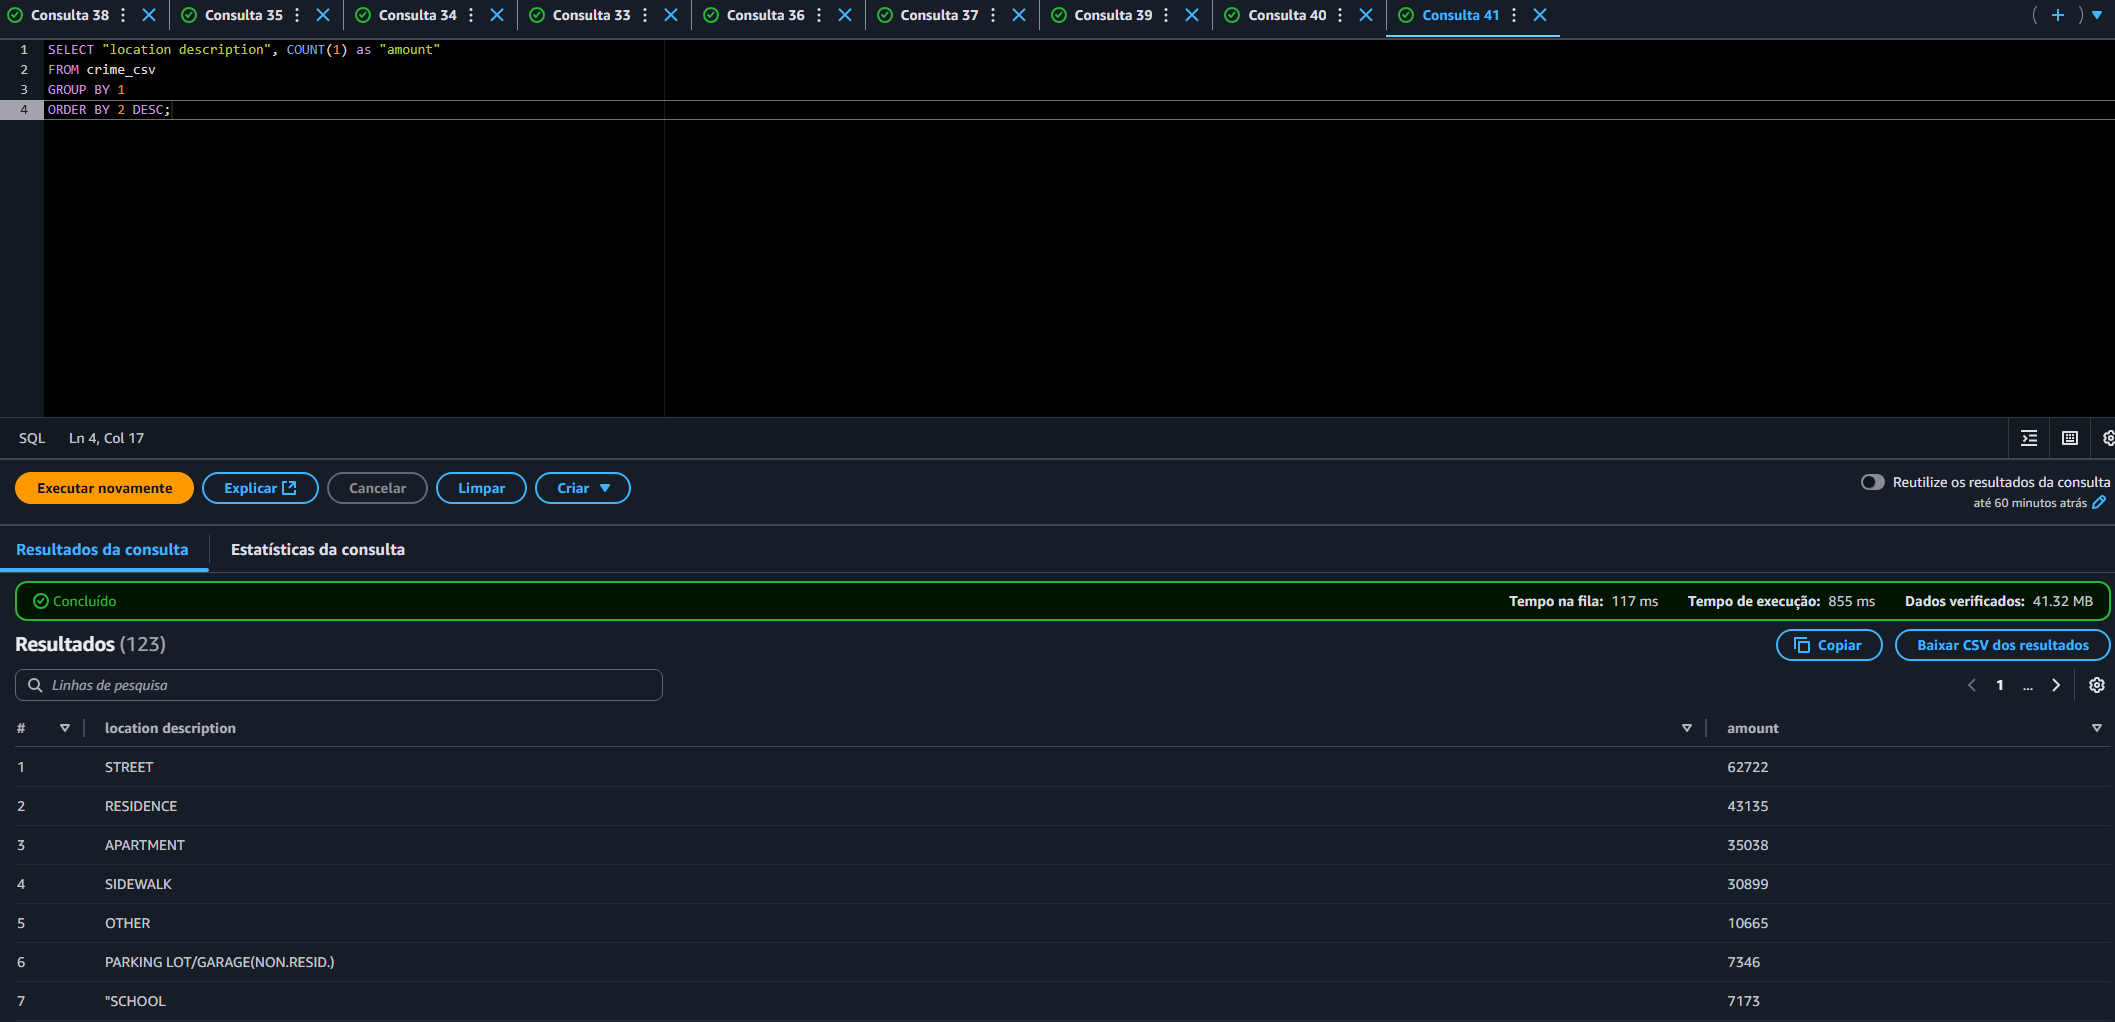

```sql
SELECT "location description", COUNT(1) as "amount"
FROM crime_parquet
GROUP BY 1
ORDER BY 2 DESC;
```
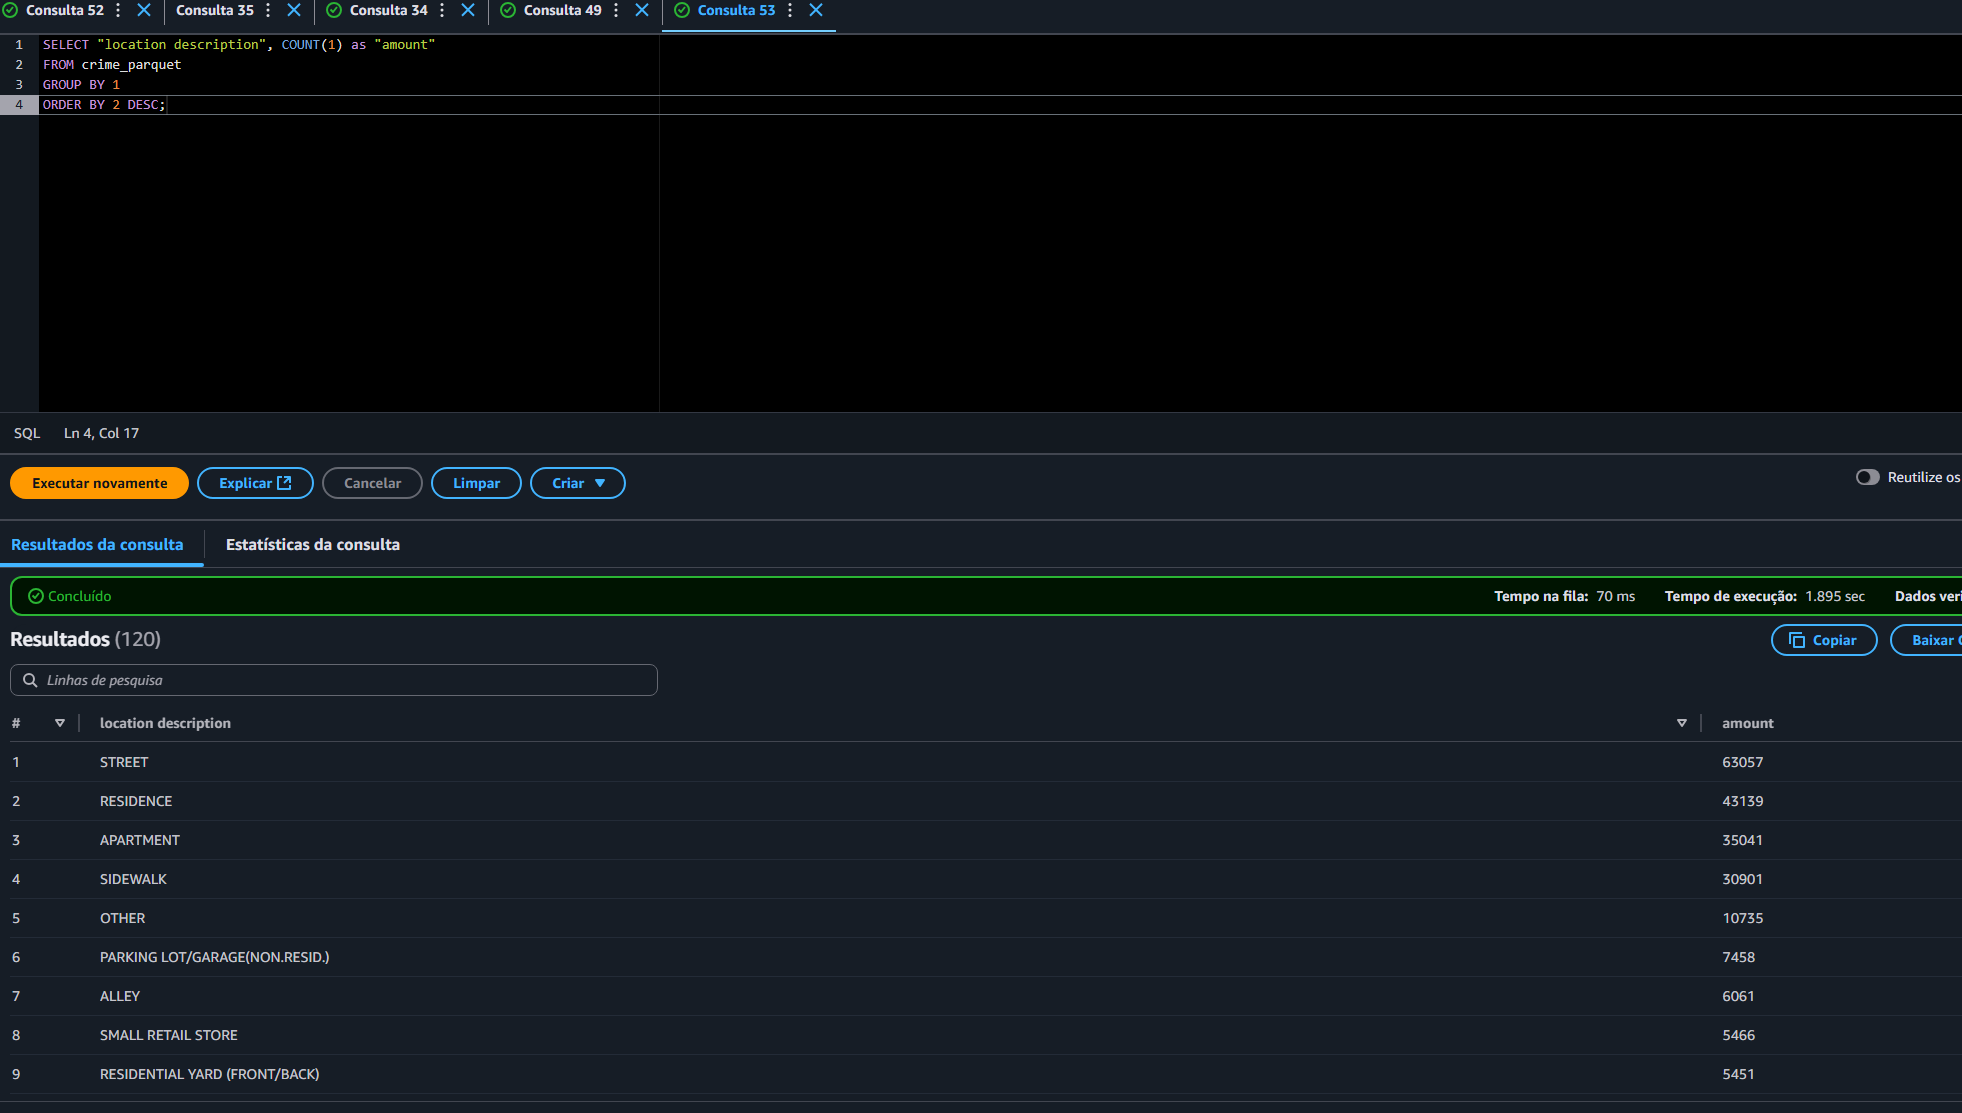

Querys 2

Este foi o código disponibilizado durante a aula. No entanto, identifiquei diversos erros nos dados, como, por exemplo, informações incorretas nas colunas. Diante disso, optei por utilizar outros códigos para realizar as análises.


```sql
SELECT *
FROM crime_csv
WHERE CAST(reference_date as DATE) BETWEEN DATE '2014-12-01' and DATE '2014-12-31'
```
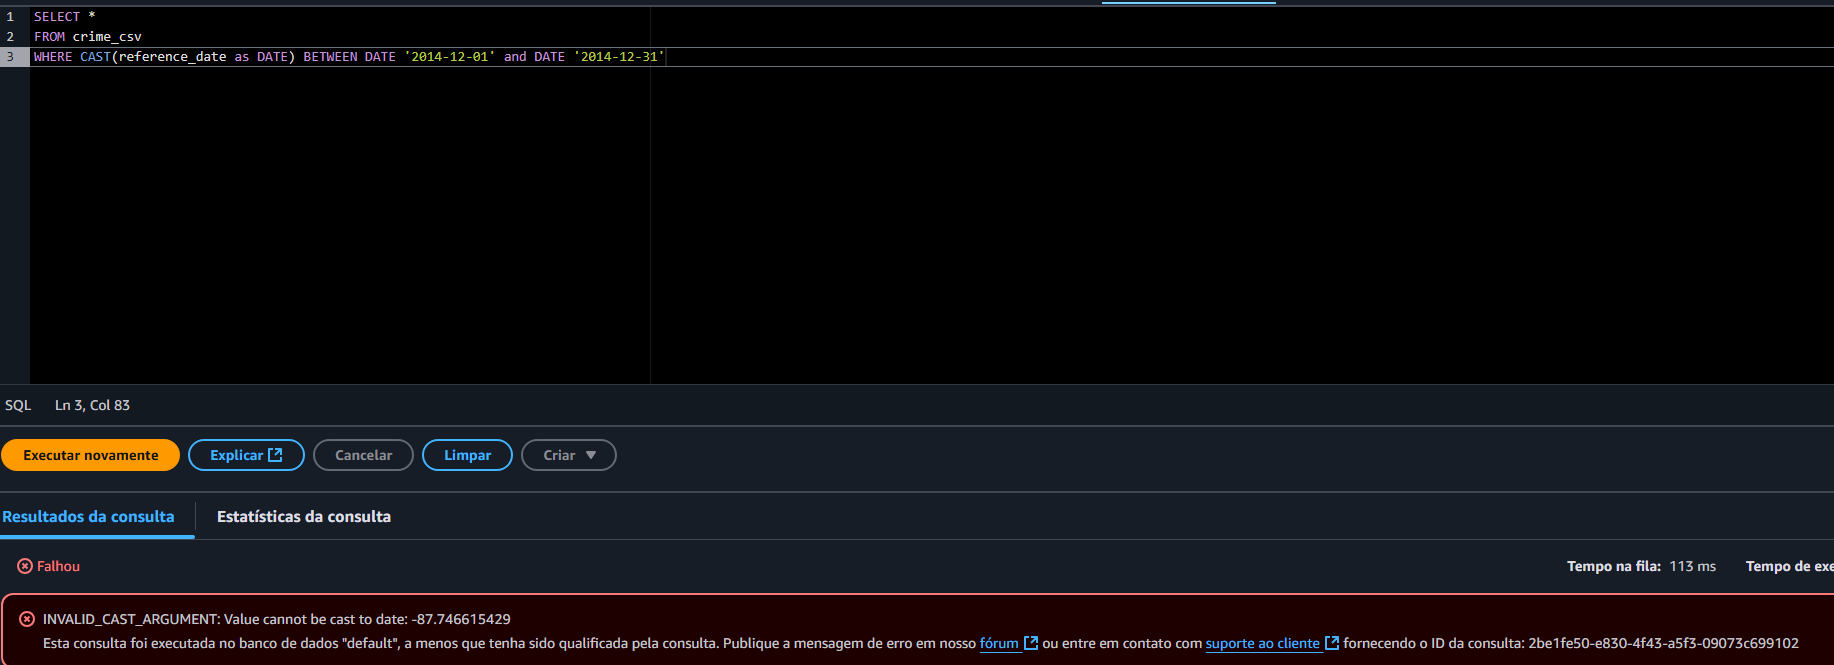


O código que deu certo.
```sql
SELECT *
FROM crime_csv
WHERE TRY_CAST(REPLACE(reference_date, '"', '') AS DATE) BETWEEN DATE '2014-12-01' AND DATE '2014-12-31';

```


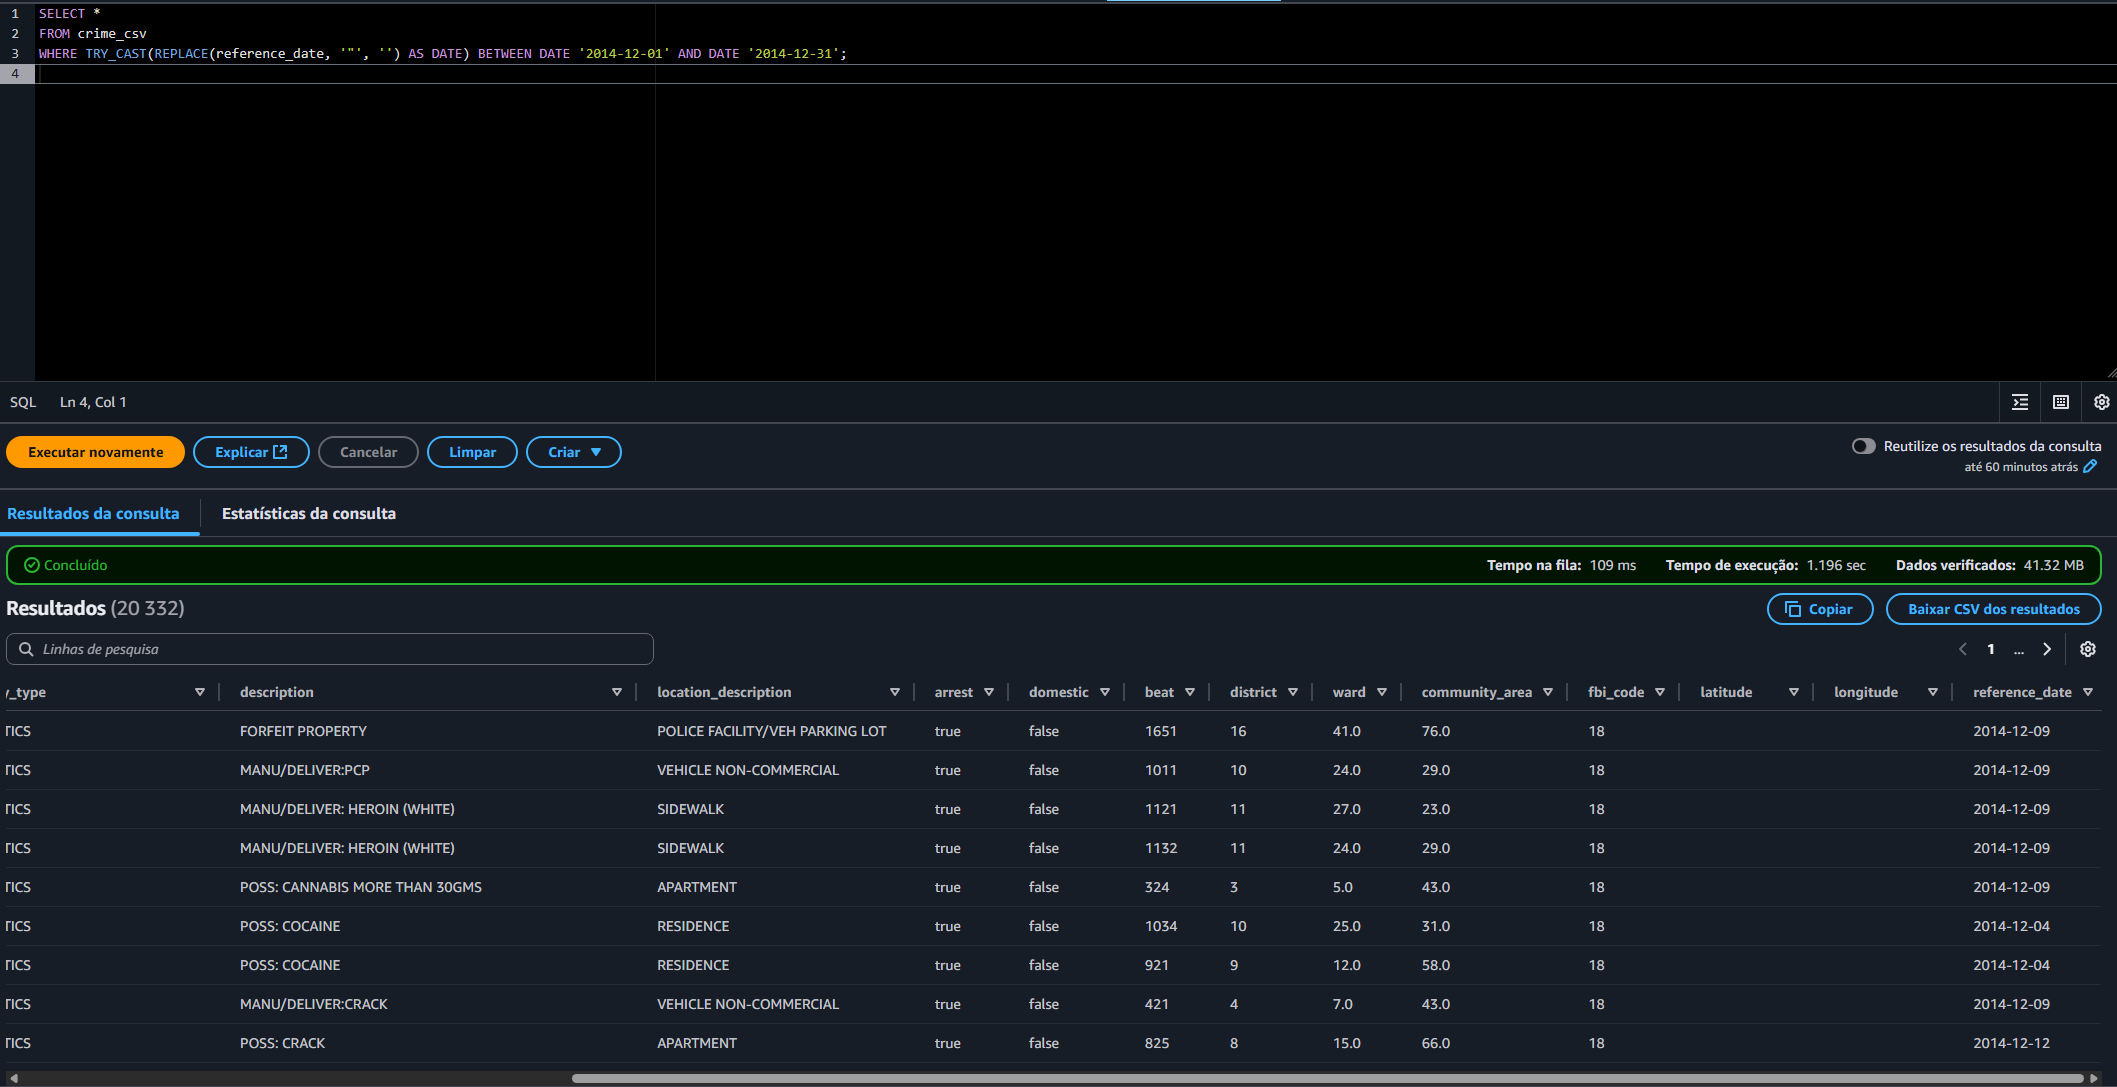


```sql
SELECT *
FROM crime_parquet
WHERE CAST(reference_date as DATE) BETWEEN DATE '2014-12-01' and DATE '2014-12-31'
```
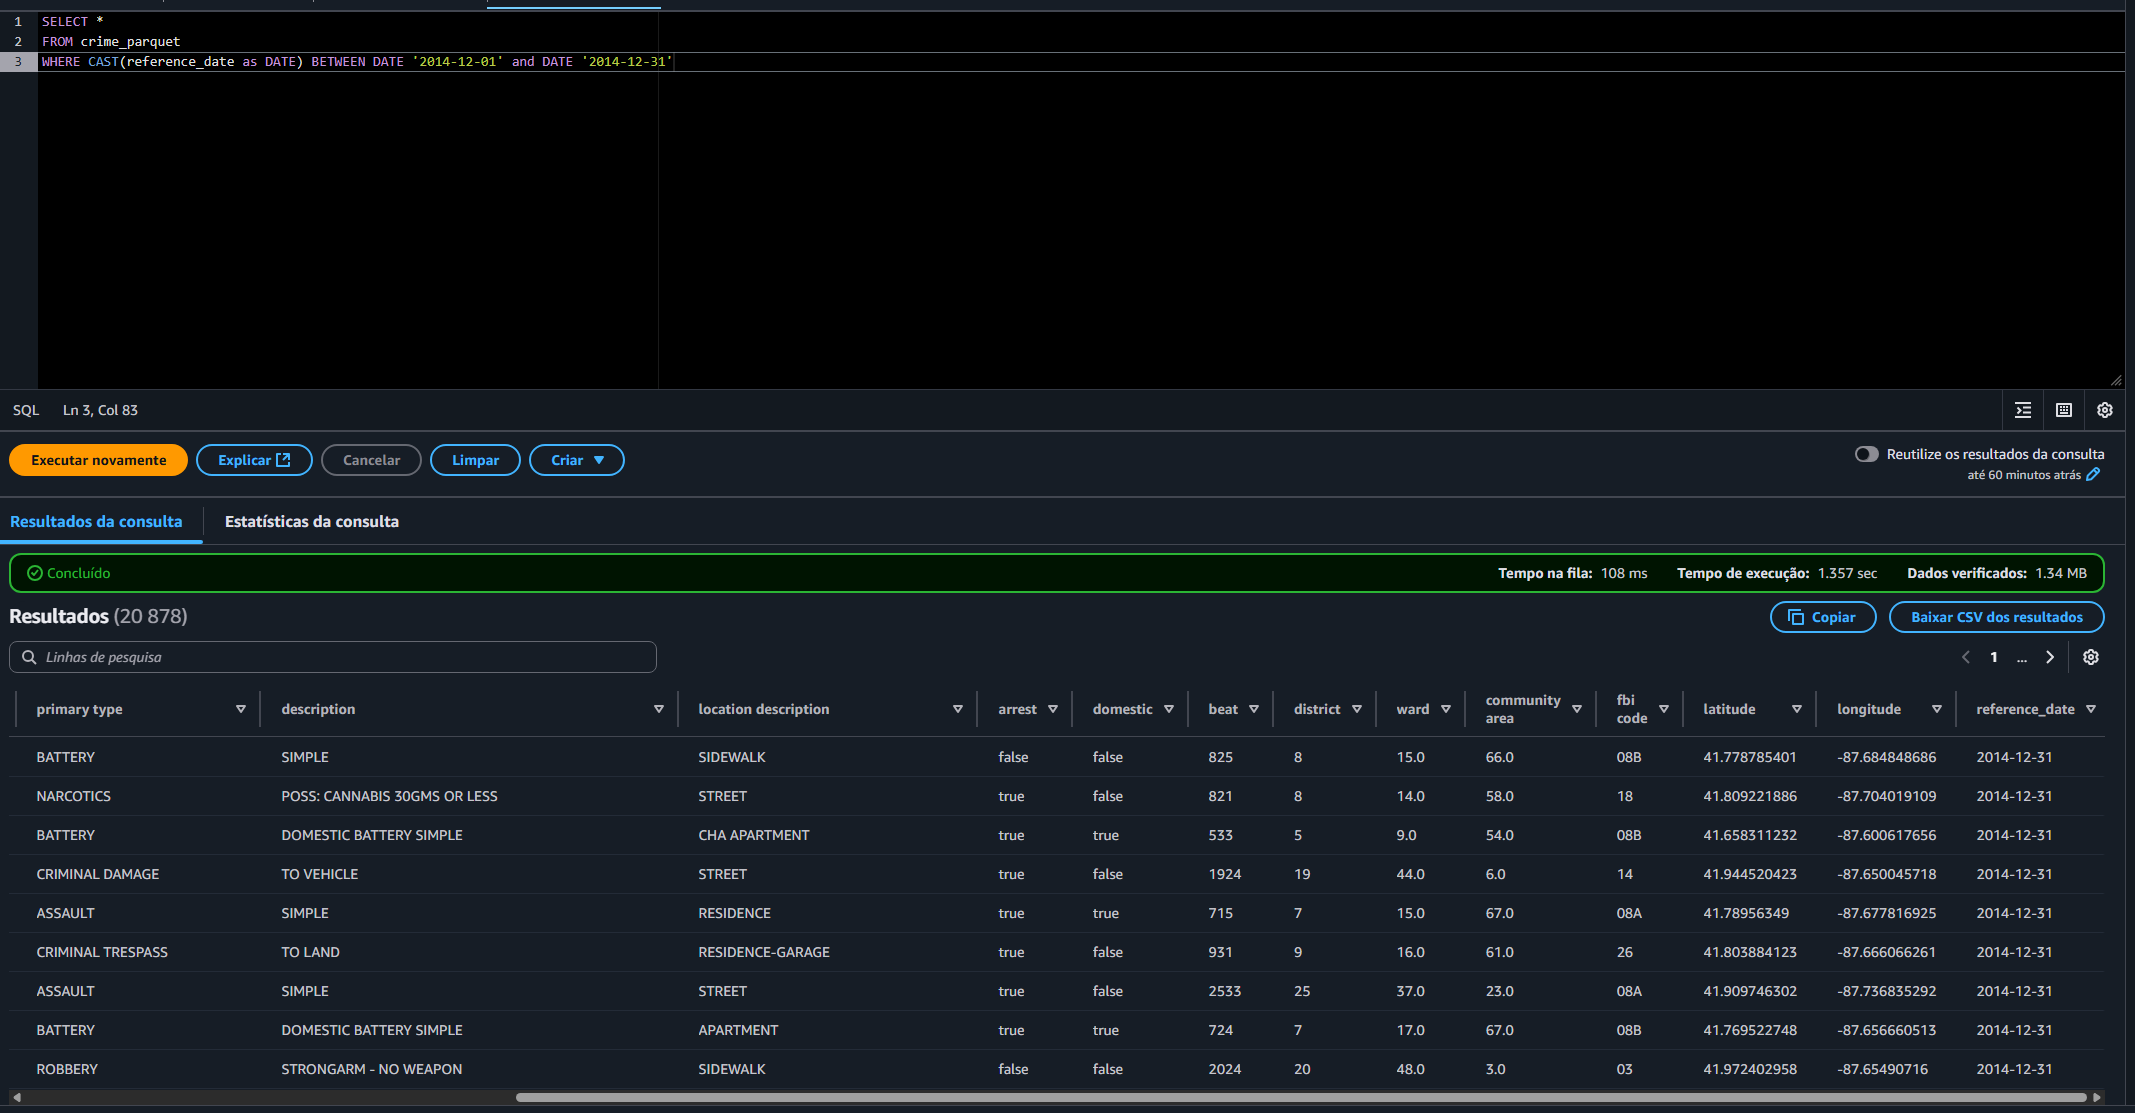

**Querys 3**

Devido o problema relatado a cima o código tambem foi corrijido.
```sql
SELECT "location_description", COUNT(1) as "amount"
FROM crime_csv
WHERE TRY_CAST(REPLACE(reference_date, '"', '') AS DATE) BETWEEN DATE '2014-12-01' AND DATE '2014-12-31'
GROUP BY 1
ORDER BY 2 DESC
```
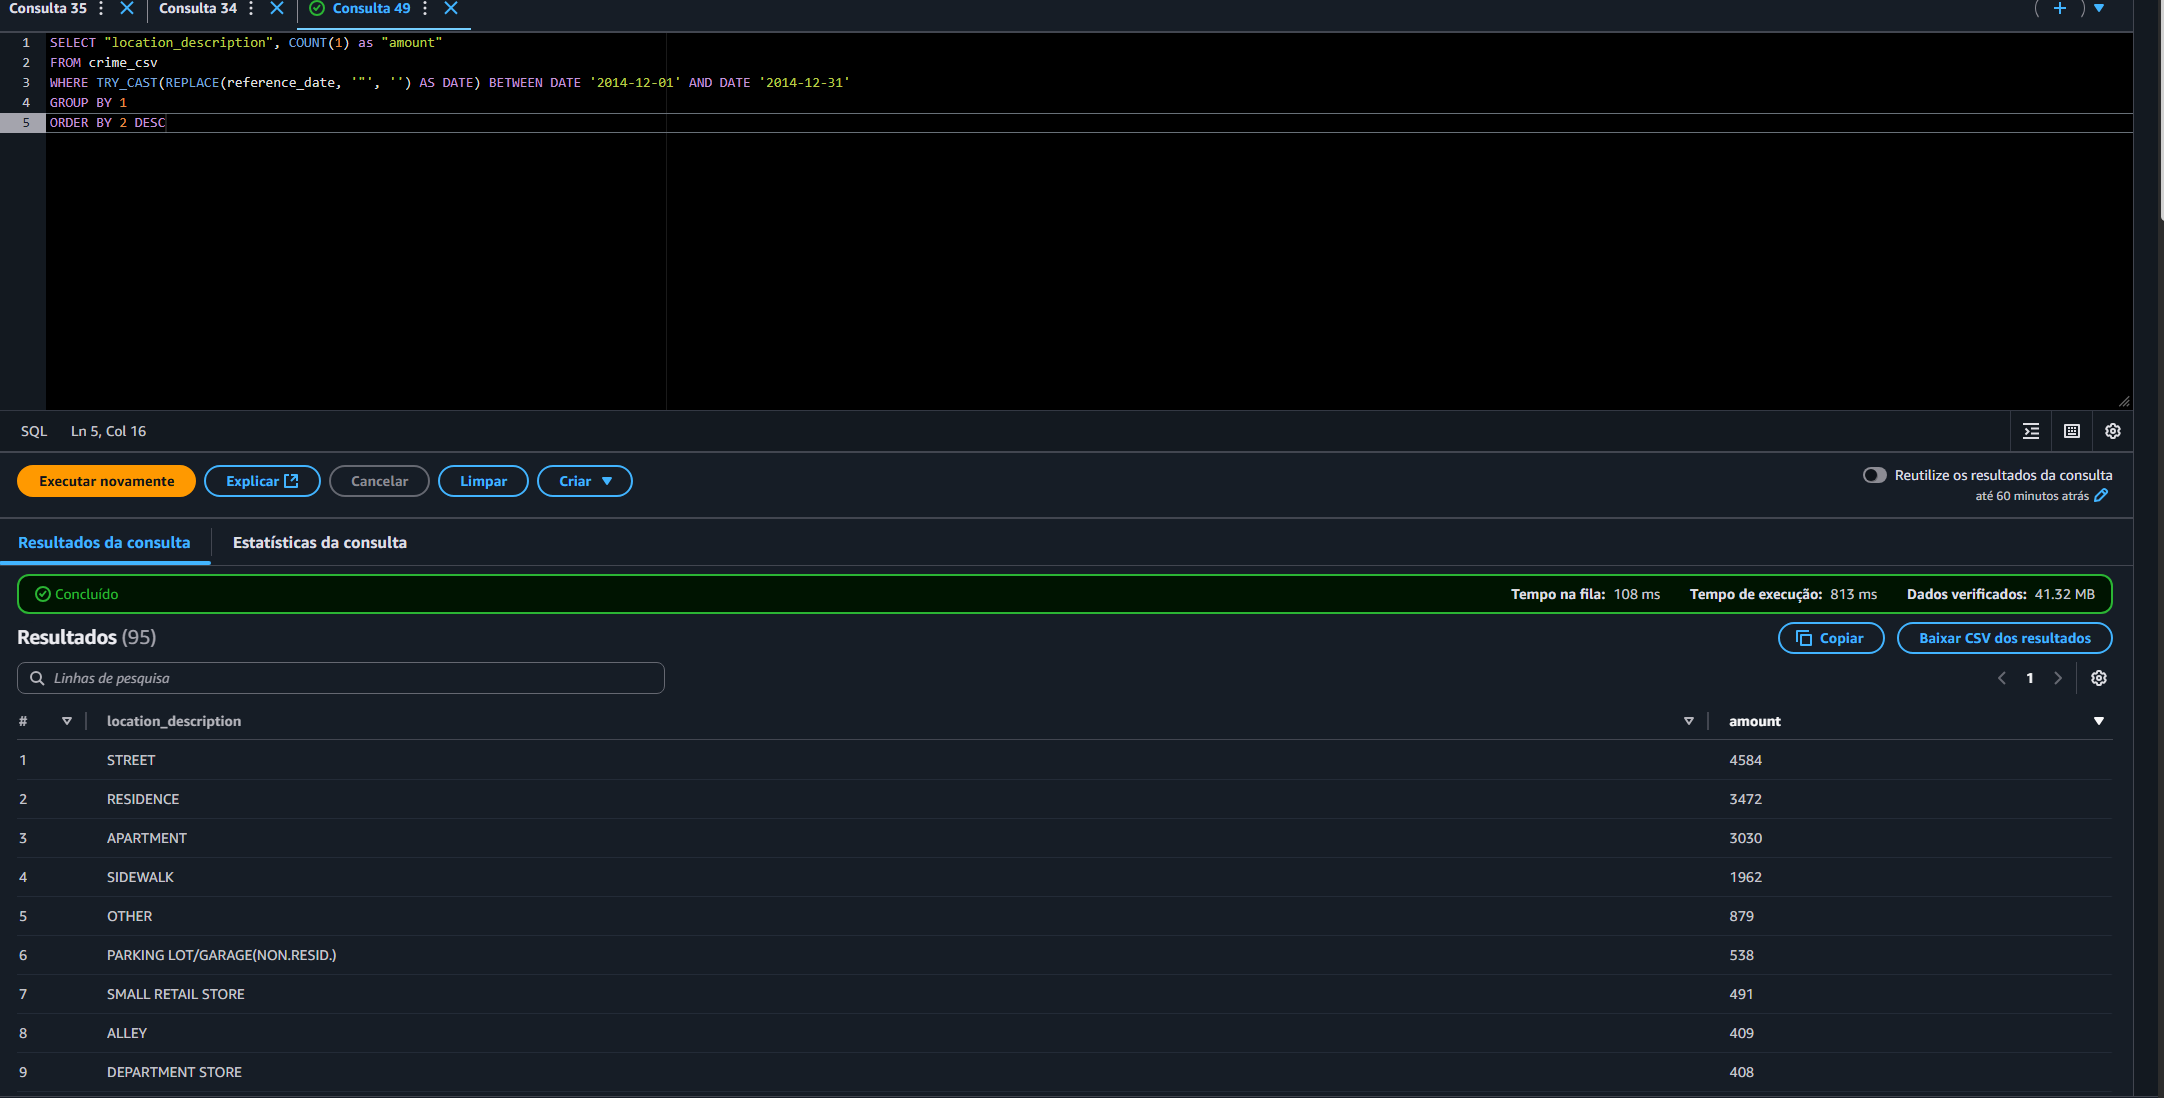

```sql
SELECT "location description", COUNT(1) as "amount"
FROM crime_parquet
WHERE CAST(reference_date as DATE) BETWEEN DATE '2014-12-01' and DATE '2014-12-31'
GROUP BY 1
ORDER BY 2 DESC
```

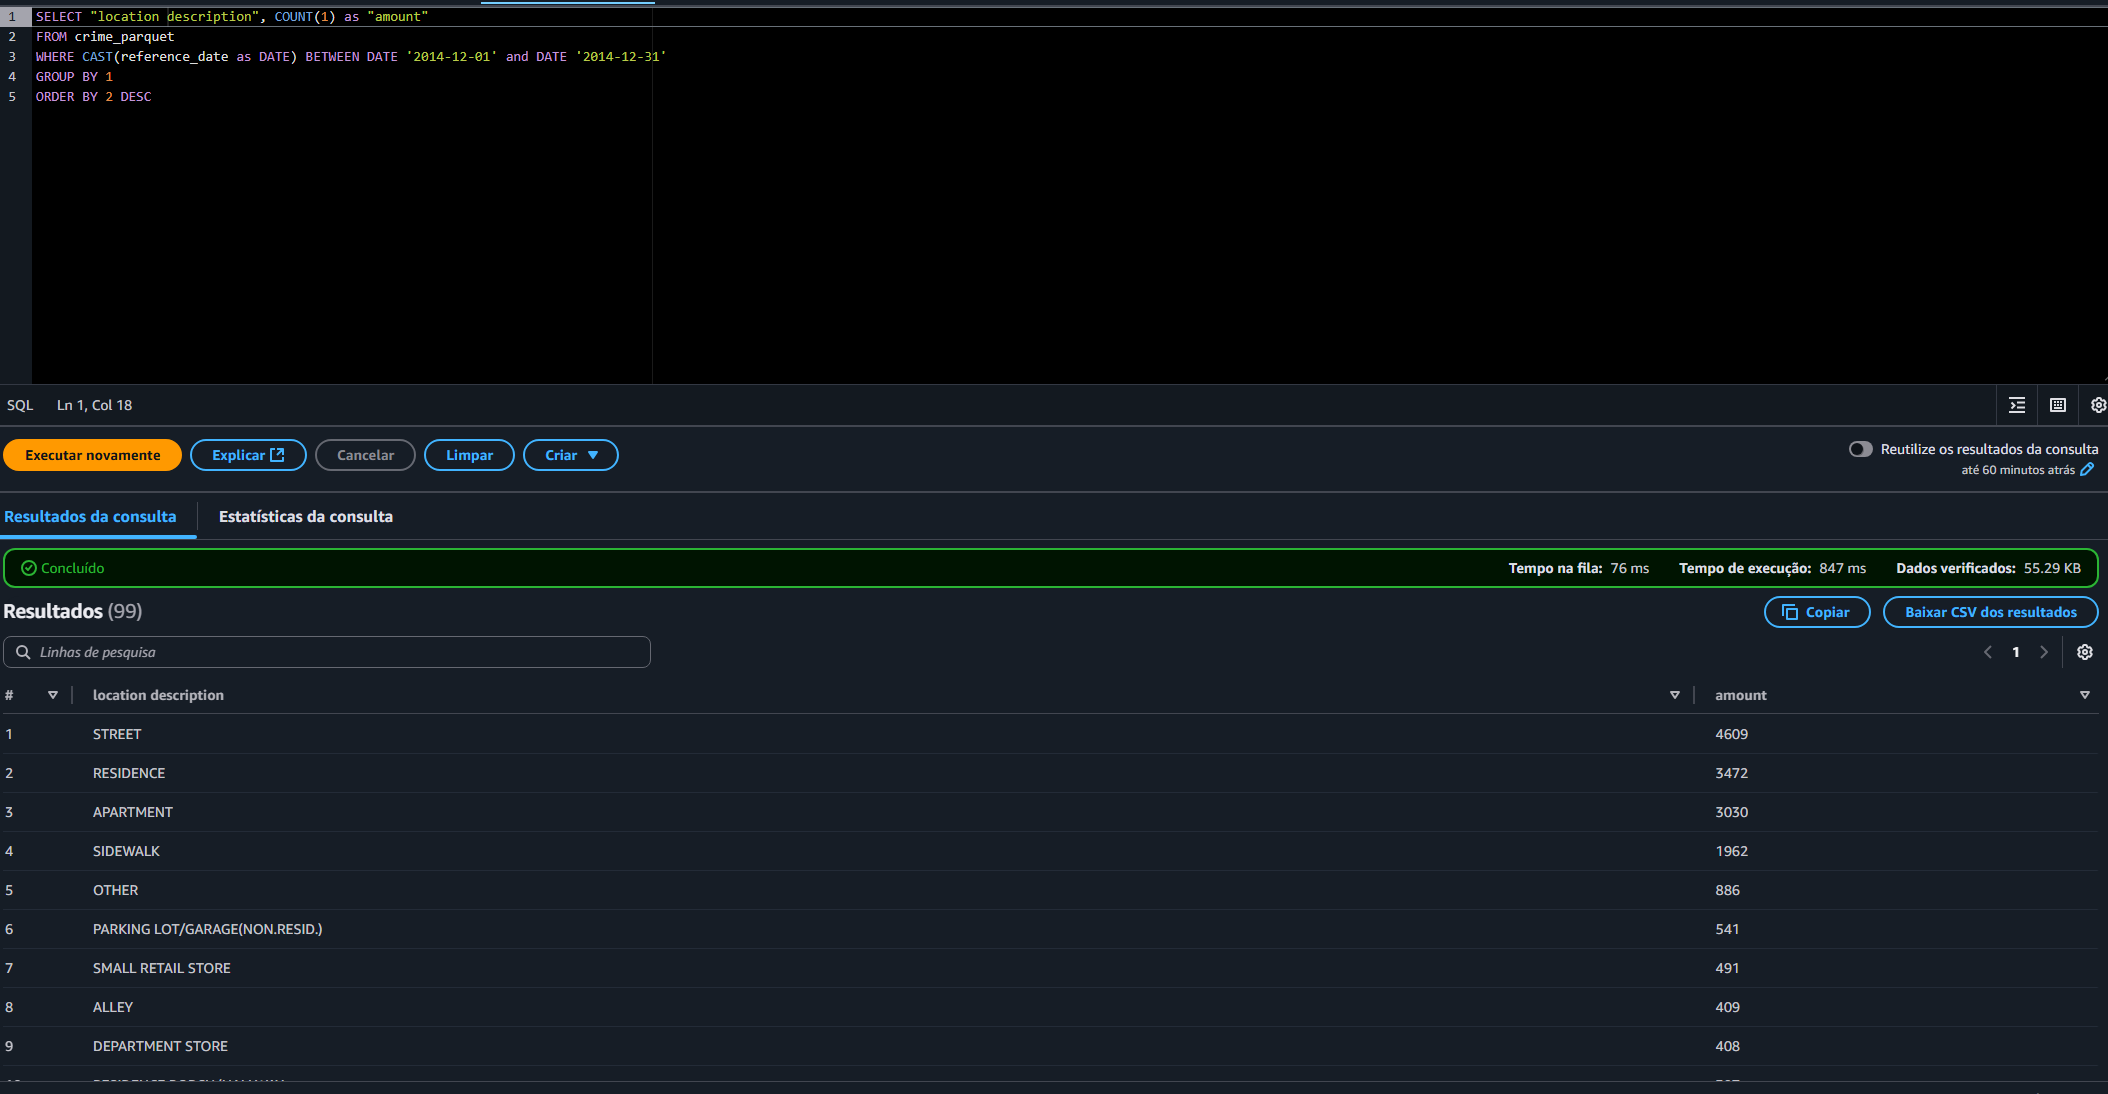
